<a href="https://colab.research.google.com/github/aliraza0321/neurofive-solutions-ML-internship/blob/main/Task%20%232%20Clean%20%26%20Visualize%20Real-World%20Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("Titanic-Dataset.csv")

In [21]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [22]:
print(df.describe())


       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [23]:
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [24]:
print(df.isnull().sum())
print(df.shape)


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
(891, 12)


In [25]:
numerical = df.select_dtypes(include='number').columns
categorical = df.select_dtypes(include='object').columns

# Fill numerical columns with their mean
for num in numerical:
    df[num] = df[num].fillna(df[num].mean())

# Fill categorical columns with their mode
for cat in categorical:
  df[cat] = df[cat].fillna(df[cat].mode()[0])

print(df.isnull().sum())
print(df.shape)

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64
(891, 12)


/tmp/ipykernel_754/1362029498.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Sex", y="Survived", ax=axes[1, 0], errorbar=None, palette="pastel")


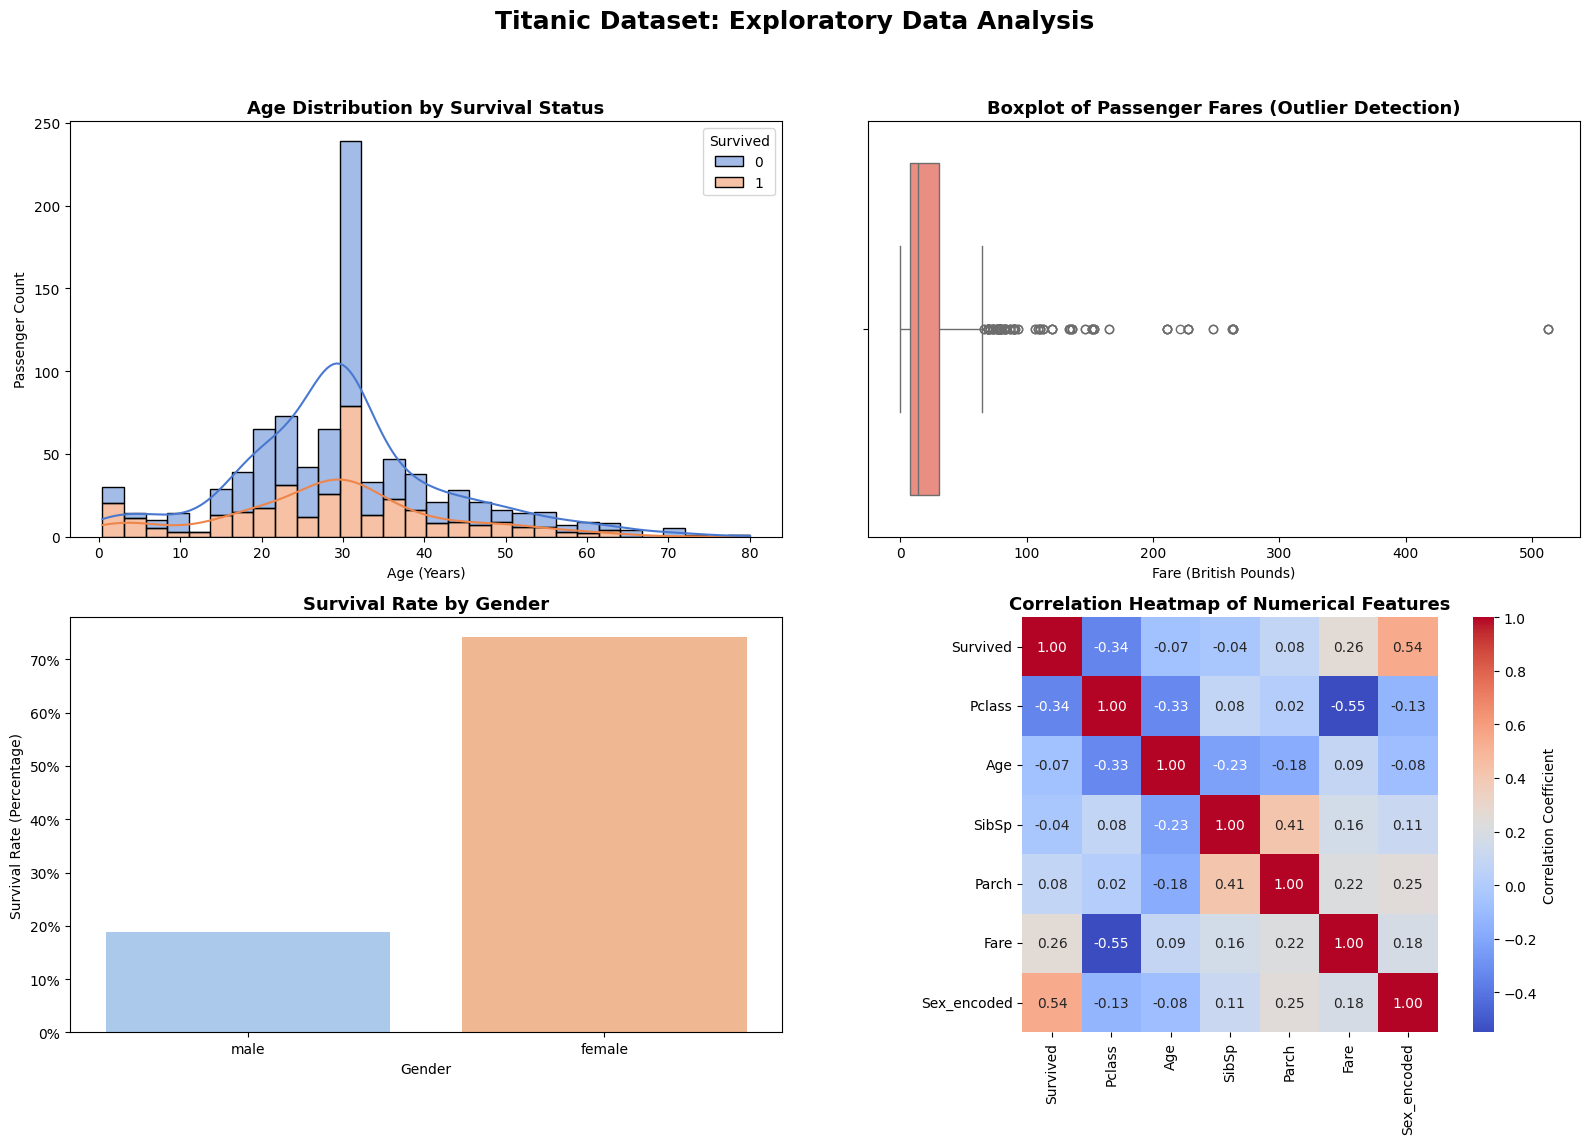

Remaining Null Values:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

Final Shape of Dataset: (891, 12)


In [26]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Titanic Dataset: Exploratory Data Analysis", fontsize=18, fontweight='bold', y=0.95)

# Histogram (Age Distribution by Survival)
sns.histplot(data=df, x="Age", hue="Survived", multiple="stack", kde=True, ax=axes[0, 0], palette="muted")
axes[0, 0].set_title("Age Distribution by Survival Status", fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel("Age (Years)")
axes[0, 0].set_ylabel("Passenger Count")

# Boxplot (Detecting Outliers in Fare)
sns.boxplot(data=df, x="Fare", ax=axes[0, 1], color="salmon")
axes[0, 1].set_title("Boxplot of Passenger Fares (Outlier Detection)", fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel("Fare (British Pounds)")

#  Bar Chart (Survival Rate by Sex)
sns.barplot(data=df, x="Sex", y="Survived", ax=axes[1, 0], errorbar=None, palette="pastel")
axes[1, 0].set_title("Survival Rate by Gender", fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel("Gender")
axes[1, 0].set_ylabel("Survival Rate (Percentage)")
axes[1, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

#  Correlation Heatmap (Numerical Features)
df_numeric = df.copy()
df_numeric['Sex_encoded'] = df_numeric['Sex'].map({'male': 0, 'female': 1})
numeric_cols = df_numeric.select_dtypes(include=['number']).drop(columns=['PassengerId'])

sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm", fmt=".2f", square=True, ax=axes[1, 1], cbar_kws={'label': 'Correlation Coefficient'})
axes[1, 1].set_title("Correlation Heatmap of Numerical Features", fontsize=13, fontweight='bold')

# Adjust layout and display
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

# Verify cleaning
print("Remaining Null Values:")
print(df.isnull().sum())
print(f"\nFinal Shape of Dataset: {df.shape}")